In [ ]:
 rm -rf ./*

#Roteiro de Aula Prática 7: Estruturas de Dados Dinâmicas (Filas - FIFO))
Este roteiro foi estruturado para guiar a realização da aula prática voltada ao estudo das Filas Dinâmicas (estruturas do tipo FIFO — First In First Out). A atividade utilizará o ambiente do Google Colab para a edição, compilação e execução de scripts na linguagem C através de diretivas de shell. O foco reside no entendimento do descritor estrutural de controle e nas operações clássicas de inserção (enfileirar) e remoção (desenfileirar) de nós dinâmicos.

## 1. Objetivos da Aula
- Compreender a regra de acesso FIFO (First In
  First Out), onde o primeiro elemento a entrar deve ser obrigatoriamente o
  primeiro a sair da estrutura.
  
- Aprender a projetar e utilizar uma estrutura de
  controle (descritor) contendo ponteiros de referência para o início e o fim da
  Fila.
  
- Implementar as operações básicas do TAD Fila:
  Criação, Enfileiramento (entra / *queue*), Desenfileiramento (sai / *dequeue*)
  e Exibição (Impressão).
  
- Desenvolver soluções práticas para problemas
  reais simulados por meio do gerenciamento de fluxos ordenados e sequenciais de
  dados.



## 2. Recursos Necessários
* Computadores com acesso ao site colab.research.google.com e/ou acesso a plataformas interativas para o desenvolvimento de aplicativos C.
* Conta ativa no Google (necessária para o uso do Google Colab).
* Conexão com a internet.
* Material de apoio (este roteiro e o notebook Google Colab correspondente, se disponível).
* Projetor para o professor.
* Ambientes alternativos: O professor poderá optar pelo uso de IDEs locais (standalone), tais como Visual Studio Code (VS Code), Code::Blocks ou Dev-C++ (Embarcadero).

# 3. Estrutura da Aula
## 3.1. Abertura e Contextualização (10 minutos)
Boas-vindas aos discentes e
contextualização prática sobre o uso das Filas na engenharia de software (como
o gerenciamento de processos prontos em sistemas operacionais, o buffer de
envio de pacotes de rede ou filas de impressão). O professor deve abrir espaço
para o debate inicial: *"Qual a diferença crucial na ordem de remoção de
dados entre uma Fila e uma Lista Convencional ou Pilha?"*
## 3.2. Revisão Conceitual (20 minutos)


O docente explicará sucintamente as diretrizes teóricas
  contidas no material unificado, respeitando o teto de 20 minutos:
  
- **O Conceito FIFO:** Destacar que em uma fila
  legítima, só podemos inserir novos dados estritamente na extremidade final
  (fim) e remover elementos apenas pela extremidade oposta (início).
  
- **O Nó vs. O Controle:** Explicar que além da
  struct No padrão (que armazena a informação e o link para o próximo), faz-se
  necessário um registro auxiliar de controle (a struct Fila) responsável por
  conter os endereços das duas pontas da fila (ini e fim).
  
- **Dinâmica de Enfileiramento:** Demonstrar
  abstratamente que ao inserir o primeiro nó, tanto o início quanto o fim apontam
  para ele; nos nós subsequentes, o ponteiro fim->proximo recebe o novo nó e o
  ponteiro global fim é atualizado.
  
- **Dinâmica de Desenfileiramento:** Demonstrar
  que ao retirar um elemento, o ponteiro de ini avança para o nó subsequente e a
  memória alocada para o nó removido é prontamente devolvida ao sistema.

#Filas

* O primeiro que entra é o primeiro que sai
* FIFO – First In First Out
* A ideia fundamental da fila é que só podemos inserir um novo elemento no final da fila e só podemos retirar o elemento que está no início da fila


###Nó



```cpp
typedef struct no{
       int info;
      struct no * proximo;
}No;
```




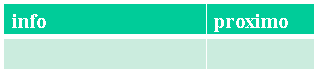

Controle: Fila







```
typedef struct fila{
  No* ini;
  No* fim;
} Fila;


```



##Criação de um controle de fila:



```cpp
Fila* cria(void){
   Fila* f = (Fila*)malloc(sizeof(Fila));
       f->ini = f->fim = NULL; /* inicia a fila vazia */
   return f;
}

```


```cpp
int main(){
  fila* f=cria();

}
```




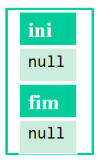

* Passar para função de enfileirar a fila e a informação.
* Inserir um novo nó.
* Caso seja o primeiro nó, atualizar o início e o fim do descritor com a referência do nó inserido.
* Caso a fila já possua informação
>* Alterar o próximo do nó criado com nulo.
>* Alterar o próximo do nó anterior com a referência do nó criado.
>* Atualizar o apontador do final da fila com a referência do nó criado.


Consolidando o TAD da Pilha



```cpp
#include <stdio.h>
#include<stdlib.h>
//-------inicio TAD--------------
typedef struct no{
       int info;
      struct no * proximo;
}No;

typedef struct fila{
  No* ini;
  No* fim;
} Fila;


Fila* cria(void){
   Fila* f = (Fila*)malloc(sizeof(Fila));
	   f->ini = f->fim = NULL; /* inicia a fila vazia */
   return f;
}

int main(){
    Fila *f = cria();
    printf("\nFila p criado no endereço %x inicio: %x fim: %x",f,f->ini, f->fim);
}
```



#Insersão na Fila

entra(pilha, valor)

* A rotina de inserção também é a mesma da lista, porém a função que insere no topo realiza o controle de uma maneira diferente, fazendo que a lista passe a ser apontada pelo elemento posterior. Na prática, é como se a lista andasse para trás


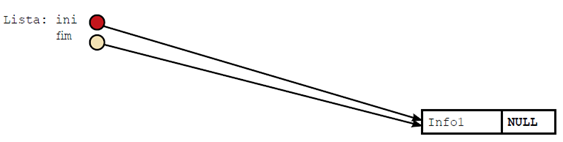

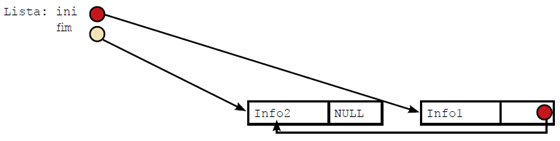

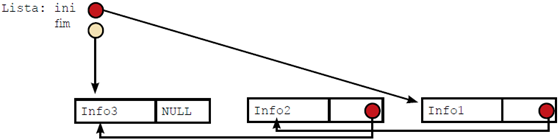



```cpp
void entra(Fila* f, int v){
   No* novo_no = insere(f->fim, v);       
   novo_no->proximo = NULL;
   if(f->fim != NULL){ /* nos casos em que não é o primeiro elemento */
      f->fim->proximo = novo_no;
	  }
   f->fim=novo_no;
   if(f->ini == NULL){ /* Fila estava vazia? */
      f->ini = f->fim;
   }
}
```



a função insere vimos em **listas**




```
No* insere(No* lista, int num){
    No* novo_no = (No*)malloc(sizeof(No));
    novo_no->info = num;
    novo_no->proximo = lista;
	  return novo_no;
}
```



##Enfileirando um valor

```cpp
Fila * f=cria();
entra(f,A);
entra(f,B);
entra(f,C);
entra(f,D);
```



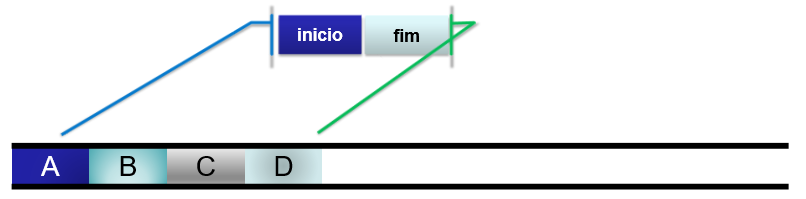

#Remoção de nó da Fila

* A remoção do nó da fila, assim como ocorre no caso da pilha, acontece sempre em um lado da sequência, nesse caso, no início


* Enviar o apontador do início nó descritor para a função *sai* (dequeue).
* Na função *sai* (dequeue)
>* Verifica se a fila não está vazia.
>* A informação do nó apontado para o início é salva.
>* Chama-se a função remove, é chamada com o topo correspondente àquela pilha selecionada.
* A função remove:
>* Salva a referência do próximo.
>* Libera o espaço.
>* Retorna a referência salva.
* Atualiza o início com a referência retornada.



```cpp
int sai(Fila* f){   //dequeue
   int v;
   if(vazia(f)){
      printf("Fila vazia.\n");
      exit(1); /* aborta programa */
   }
   v = f->ini->info;
   f->ini = retira(f->ini);
   if(f->ini == NULL){ /* Fila ficou vazia? */
      f->fim = NULL;
   }
   return v;
}
```



```
No* retira(No* lista){
    No* aux = lista;
    lista = aux->proximo;
    free(aux);
    return lista;
}
```




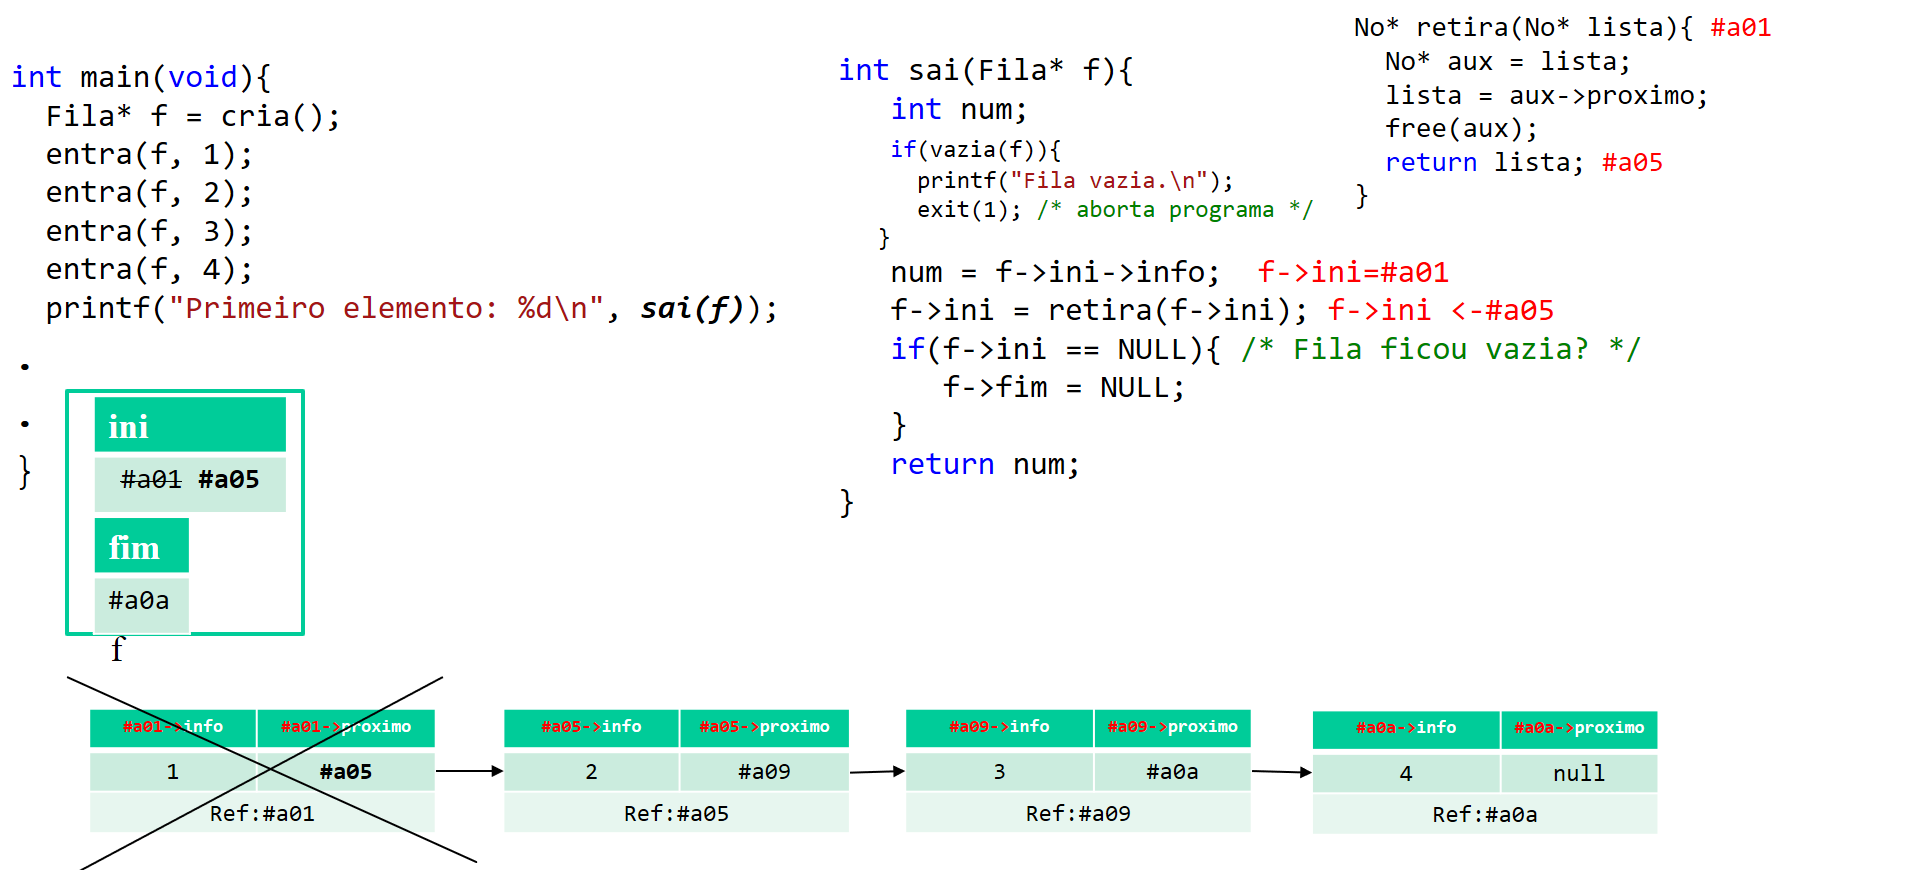

# TAD FILA


```
#include<stdio.h>
#include<stdlib.h>

typedef struct no{
	int info;
	struct no * proximo;
}No;

typedef struct fila{
	No* ini;
	No* fim;
}Fila;

No* insere(No* lista, int num){
	No* novo_no = (No*)malloc(sizeof(No));
	novo_no->info = num;
	novo_no->proximo = lista;
	return novo_no;
}

No* retira(No* lista){
	No* aux = lista;
	lista = aux->proximo;
	free(aux);
	return lista;
}

Fila* cria(void){
	Fila* f = (Fila*)malloc(sizeof(Fila));
	f->ini = f->fim = NULL; /* inicia a fila vazia */
	return f;
}

void entra(Fila* f, int v){      //queue
   No* novo_no = insere(f->fim, v);       
   novo_no->proximo = NULL;
   if(f->fim != NULL){ /* nos casos em que não é o primeiro elemento */
      f->fim->proximo = novo_no;
	  }
   f->fim=novo_no;
   if(f->ini == NULL){ /* Fila estava vazia? */
      f->ini = f->fim;
   }
}

int vazia(Fila* f){
	return(f->ini == NULL);
}

int sai(Fila* f){   //dequeue
   int v;
   if(vazia(f)){
      printf("Fila vazia.\n");
      exit(1); /* aborta programa */
   }
   v = f->ini->info;
   f->ini = retira(f->ini);
   if(f->ini == NULL){ /* Fila ficou vazia? */
      f->fim = NULL;
   }
   return v;
}

void libera(Fila* f){
	No* q = f->ini;
	while(q != NULL){
		No* t = q->proximo;
		free(q);
		q = t;
	}
	free(f);
}

void imprime(Fila* f){
	No* q;
	for(q = f->ini; q != NULL; q = q->proximo){
		printf("%d\n", q->info);
	}
}
```



## 3.3. Demonstração Prática (30 minutos)

###Criação da fila

In [ ]:
%%writefile exemplo601.c
#include <stdio.h>
#include<stdlib.h>
//-------inicio TAD--------------
typedef struct no{
       int info;
      struct no * proximo;
}No;

typedef struct fila{
  No* ini;
  No* fim;
} Fila;


Fila* cria(void){
   Fila* f = (Fila*)malloc(sizeof(Fila));
	   f->ini = f->fim = NULL; /* inicia a fila vazia */
   return f;
}

int main(){
    Fila *f = cria();
    printf("\nFila p criado no endereço %x inicio: %x fim: %x",f,f->ini, f->fim);
}

Writing exemplo601.c


In [ ]:
%%shell

gcc exemplo601.c -w -o programa

./programa


Fila p criado no endereço fa3592a0 inicio: 0 fim: 0

###Enfileirar (queue)

##Enfileirando um valor

In [ ]:
%%writefile exemplo602.c
#include<stdio.h>
#include<stdlib.h>

typedef struct no{
	int info;
	struct no * proximo;
}No;

typedef struct fila{
	No* ini;
	No* fim;
}Fila;

No* insere(No* lista, int num){
	No* novo_no = (No*)malloc(sizeof(No));
	novo_no->info = num;
	novo_no->proximo = lista;
	return novo_no;
}

No* retira(No* lista){
	No* aux = lista;
	lista = aux->proximo;
	free(aux);
	return lista;
}

Fila* cria(void){
	Fila* f = (Fila*)malloc(sizeof(Fila));
	f->ini = f->fim = NULL; /* inicia a fila vazia */
	return f;
}

void entra(Fila* f, int v){
   No* novo_no = insere(f->fim, v);
   novo_no->proximo = NULL;
   if(f->fim != NULL){ /* nos casos em que não é o primeiro elemento */
      f->fim->proximo = novo_no;
	  }
   f->fim=novo_no;
   if(f->ini == NULL){ /* Fila estava vazia? */
      f->ini = f->fim;
   }
}

int vazia(Fila* f){
	return(f->ini == NULL);
}


void libera(Fila* f){
	No* q = f->ini;
	while(q != NULL){
		No* t = q->proximo;
		free(q);
		q = t;
	}
	free(f);
}

void imprime(Fila* f){
	No* q;
	for(q = f->ini; q != NULL; q = q->proximo){
		printf("%d\n", q->info);
	}
}

void imprimef(Fila* f){
	No* q;
	printf("\nfila inicio:%x ",f->ini) ;
	for(q = f->ini; q != NULL; q = q->proximo){
		printf("\n(%x)|info:%10d|prox: %x|",q, q->info,q->proximo);
	}
	printf("\n fila fim:%x ",f->fim);

}

int main(void){
	Fila* f = cria();
  printf("\nFila p criado no endereço %x inicio: %x fim: %x",f,f->ini, f->fim);
	entra(f, 1);
  printf("\n\n No criado em %x conteudo %d proximo:%x",f->fim, f->fim->info,f->fim->proximo);
  printf("\nFila inicio: %x fim: %x",f->ini, f->fim);

	entra(f, 2);
  printf("\n\n No criado em %x conteudo %d proximo:%x",f->fim, f->fim->info,f->fim->proximo);
  printf("\nFila inicio: %x fim: %x",f->ini, f->fim);

	entra(f, 3);
  printf("\n\n No criado em %x conteudo %d proximo:%x",f->fim, f->fim->info,f->fim->proximo);
  printf("\nFila inicio: %x fim: %x",f->ini, f->fim);

	entra(f, 4);
  printf("\n\n No criado em %x conteudo %d proximo:%x",f->fim, f->fim->info,f->fim->proximo);
  printf("\nFila inicio: %x fim: %x",f->ini, f->fim);

	printf("Configuracao da fila:\n");
	imprimef(f);
	printf("\nFila inicio: %x fim: %x",f->ini, f->fim);
return 0;
}


Overwriting exemplo602.c


In [ ]:
%%shell

gcc exemplo602.c -w -o programa

./programa


Fila p criado no endereço c7eab2a0 inicio: 0 fim: 0

 No criado em c7eab6d0 conteudo 1 proximo:0
Fila inicio: c7eab6d0 fim: c7eab6d0

 No criado em c7eab6f0 conteudo 2 proximo:0
Fila inicio: c7eab6d0 fim: c7eab6f0

 No criado em c7eab710 conteudo 3 proximo:0
Fila inicio: c7eab6d0 fim: c7eab710

 No criado em c7eab730 conteudo 4 proximo:0
Fila inicio: c7eab6d0 fim: c7eab730Configuracao da fila:

fila inicio:c7eab6d0 
(c7eab6d0)|info:         1|prox: c7eab6f0|
(c7eab6f0)|info:         2|prox: c7eab710|
(c7eab710)|info:         3|prox: c7eab730|
(c7eab730)|info:         4|prox: 0|
 fila fim:c7eab730 
Fila inicio: c7eab6d0 fim: c7eab730

#Remoção de nó da Fila

* A remoção do nó da fila, assim como ocorre no caso da pilha, acontece sempre em um lado da sequência, nesse caso, no início


In [ ]:
%%writefile exemplo602.c
#include<stdio.h>
#include<stdlib.h>

typedef struct no{
	int info;
	struct no * proximo;
}No;

typedef struct fila{
	No* ini;
	No* fim;
}Fila;

No* insere(No* lista, int num){
	No* novo_no = (No*)malloc(sizeof(No));
	novo_no->info = num;
	novo_no->proximo = lista;
	return novo_no;
}

No* retira(No* lista){
	No* aux = lista;
	lista = aux->proximo;
	free(aux);
	return lista;
}

Fila* cria(void){
	Fila* f = (Fila*)malloc(sizeof(Fila));
	f->ini = f->fim = NULL; /* inicia a fila vazia */
	return f;
}

void entra(Fila* f, int v){
   No* novo_no = insere(f->fim, v);
   novo_no->proximo = NULL;
   if(f->fim != NULL){ /* nos casos em que não é o primeiro elemento */
      f->fim->proximo = novo_no;
	  }
   f->fim=novo_no;
   if(f->ini == NULL){ /* Fila estava vazia? */
      f->ini = f->fim;
   }
}

int vazia(Fila* f){
	return(f->ini == NULL);
}

int sai(Fila* f){
   int v;
   if(vazia(f)){
      printf("Fila vazia.\n");
      exit(1); /* aborta programa */
   }
   v = f->ini->info;
   f->ini = retira(f->ini);
   if(f->ini == NULL){ /* Fila ficou vazia? */
      f->fim = NULL;
   }
   return v;
}

void libera(Fila* f){
	No* q = f->ini;
	while(q != NULL){
		No* t = q->proximo;
		free(q);
		q = t;
	}
	free(f);
}

void imprime(Fila* f){
	No* q;
	for(q = f->ini; q != NULL; q = q->proximo){
		printf("%d\n", q->info);
	}
}
void imprimef(Fila* f){
	No* q;
	printf("\nfila inicio:%x ",f->ini) ;
	for(q = f->ini; q != NULL; q = q->proximo){
		printf("\n(%x)|info:%10d|prox: %x|",q, q->info,q->proximo);
	}
	printf("\n fila fim:%x \n",f->fim);

}

int main(void){
	Fila* f = cria();
	entra(f, 1);
	entra(f, 2);
	entra(f, 3);
	entra(f, 4);
	imprimef(f);
	printf("Primeiro elemento: %d\n", sai(f));
	printf("Segundo elemento: %d\n", sai(f));
	printf("Configuracao da fila:\n");
	imprimef(f);
	entra(f, 5);
	entra(f, 6);
	printf("Configuracao da fila:\n");
	imprimef(f);
	printf("terceiro elemento: %d\n", sai(f));
	printf("Configuracao da fila:\n");
	imprimef(f);
	libera(f);
	return 0;
}


In [ ]:
%%shell

gcc exemplo602.c -w -o programa

./programa

## 4. Atividades Práticas (40 minutos)
### 4.1 Desafio Inicial: Sistema de senhas


Implemente um programa em C que simule o funcionamento de um sistema de senhas em uma clínica.

O sistema deve permitir:

1. Retirar senha (entrar na fila)
2. Chamar próximo paciente (sair da fila)
3. Mostrar a fila atual
4. Encerrar o programa

---

## Regras

- Utilize exclusivamente a TAD de fila fornecida
- As senhas devem ser automáticas e sequenciais (1, 2, 3...)
- A fila deve respeitar a ordem de chegada (FIFO)

---

##  Menu esperado

```
1 - Retirar senha
2 - Chamar proximo
3 - Mostrar fila
0 - Sair
```

---

## Exemplo de Execução

```
Opcao: 1
Senha retirada: 1

Opcao: 1
Senha retirada: 2

Opcao: 1
Senha retirada: 3

Opcao: 3
Fila atual:
1
2
3

Opcao: 2
Senha chamada: 1

Opcao: 3
Fila atual:
2
3
```

---

## 💡 Lógica esperada

- Usar uma variável int senha = 1;

Ao retirar senha:

```c
entra(fila, senha);
senha++;
```

Ao chamar paciente:

```c
sai(fila);
```

---


In [ ]:
%%writefile desafio.c
#include <stdio.h>
#include <stdlib.h>

/* ===== TAD FORNECIDA ===== */

typedef struct no{
    int info;
    struct no * proximo;
}No;

typedef struct fila{
    No* ini;
    No* fim;
}Fila;

No* insere(No* lista, int num){
    No* novo_no = (No*)malloc(sizeof(No));
    novo_no->info = num;
    novo_no->proximo = lista;
    return novo_no;
}

No* retira(No* lista){
    No* aux = lista;
    lista = aux->proximo;
    free(aux);
    return lista;
}

Fila* cria(void){
    Fila* f = (Fila*)malloc(sizeof(Fila));
    f->ini = f->fim = NULL;
    return f;
}

void entra(Fila* f, int v){
   No* novo_no = insere(f->fim, v);
   novo_no->proximo = NULL;

   if(f->fim != NULL){
      f->fim->proximo = novo_no;
   }

   f->fim = novo_no;

   if(f->ini == NULL){
      f->ini = f->fim;
   }
}

int vazia(Fila* f){
    return(f->ini == NULL);
}

int sai(Fila* f){
   int v;

   if(vazia(f)){
      printf("Fila vazia.\n");
      return -1;
   }

   v = f->ini->info;
   f->ini = retira(f->ini);

   if(f->ini == NULL){
      f->fim = NULL;
   }

   return v;
}

void imprime(Fila* f){
    No* q;
    for(q = f->ini; q != NULL; q = q->proximo){
        printf("%d\n", q->info);
    }
}

/* ===== PROGRAMA PRINCIPAL ===== */

int main(){
    Fila *fila = cria();
    int opcao;
    int senha = 1;  // contador de senhas

    do{
        printf("\n1 - Retirar senha\n");
        printf("2 - Chamar proximo\n");
        printf("3 - Mostrar fila\n");
        printf("0 - Sair\n");
        printf("Opcao: ");
        scanf("%d", &opcao);

        switch(opcao){

            case 1:
                entra(fila, senha);
                printf("Senha retirada: %d\n", senha);
                senha++;
                break;

            case 2: {
                int chamada = sai(fila);
                if(chamada != -1){
                    printf("Senha chamada: %d\n", chamada);
                }
                break;
            }

            case 3:
                if(vazia(fila)){
                    printf("Fila vazia.\n");
                } else {
                    printf("Fila atual:\n");
                    imprime(fila);
                }
                break;

            case 0:
                printf("Encerrando programa...\n");
                break;

            default:
                printf("Opcao invalida!\n");
        }

    }while(opcao != 0);

    return 0;
}



Overwriting desafio.c


In [ ]:
%%shell

gcc desafio.c -w -o programa

./programa

### 4.2 Ampliação do Desafio: FIla Prioritária



O sistema deve utilizar **duas filas distintas**:

1. Fila de atendimento normal
2. Fila de atendimento prioritário

### Regras do sistema:

- As senhas devem ser geradas automaticamente:
  - Senhas normais iniciam em **1** (1, 2, 3...)
  - Senhas prioritárias iniciam em **100** (100, 101, 102...)

- O atendimento deve seguir a seguinte lógica:
  - Sempre atender primeiro quem estiver na **fila prioritária**
  - Se a fila prioritária estiver vazia, atender da **fila normal**

---

## Funcionalidades

O programa deve apresentar o seguinte menu:

```
1 - Retirar senha normal
2 - Retirar senha prioritária
3 - Chamar próximo paciente
4 - Mostrar filas
0 - Sair
```

---

## Exemplo de execução

```
Opcao: 1
Senha normal retirada: 1

Opcao: 2
Senha prioritária retirada: 100

Opcao: 2
Senha prioritária retirada: 101

Opcao: 3
Chamando senha prioritária: 100

Opcao: 3
Chamando senha prioritária: 101

Opcao: 3
Chamando senha normal: 1
```


In [ ]:
%%writefile desafio.c
#include <stdio.h>
#include <stdlib.h>

/* ===== TAD ===== */

typedef struct no{
    int info;
    struct no * proximo;
}No;

typedef struct fila{
    No* ini;
    No* fim;
}Fila;

No* insere(No* lista, int num){
    No* novo_no = (No*)malloc(sizeof(No));
    novo_no->info = num;
    novo_no->proximo = lista;
    return novo_no;
}

No* retira(No* lista){
    No* aux = lista;
    lista = aux->proximo;
    free(aux);
    return lista;
}

Fila* cria(void){
    Fila* f = (Fila*)malloc(sizeof(Fila));
    f->ini = f->fim = NULL;
    return f;
}

void entra(Fila* f, int v){
    No* novo_no = insere(f->fim, v);
    novo_no->proximo = NULL;

    if(f->fim != NULL){
        f->fim->proximo = novo_no;
    }

    f->fim = novo_no;

    if(f->ini == NULL){
        f->ini = f->fim;
    }
}

int vazia(Fila* f){
    return(f->ini == NULL);
}

int sai(Fila* f){
    int v;

    if(vazia(f)){
        return -1;
    }

    v = f->ini->info;
    f->ini = retira(f->ini);

    if(f->ini == NULL){
        f->fim = NULL;
    }

    return v;
}

void imprime(Fila* f){
    No* q;
    for(q = f->ini; q != NULL; q = q->proximo){
        printf("%d\n", q->info);
    }
}

/* ===== PROGRAMA PRINCIPAL ===== */

int main(){

    Fila *normal = cria();
    Fila *prioritaria = cria();

    int senhaNormal = 1;
    int senhaPrioritaria = 100;

    int opcao;

    do{
        printf("\n1 - Senha normal\n");
        printf("2 - Senha prioritária\n");
        printf("3 - Chamar próximo\n");
        printf("4 - Mostrar filas\n");
        printf("0 - Sair\n");
        printf("Opcao: ");
        scanf("%d", &opcao);

        switch(opcao){

            case 1:
                entra(normal, senhaNormal);
                printf("Senha normal retirada: %d\n", senhaNormal);
                senhaNormal++;
                break;

            case 2:
                entra(prioritaria, senhaPrioritaria);
                printf("Senha prioritária retirada: %d\n", senhaPrioritaria);
                senhaPrioritaria++;
                break;

            case 3: {
                int chamada;

                if(!vazia(prioritaria)){
                    chamada = sai(prioritaria);
                    printf("Chamando senha prioritária: %d\n", chamada);
                }
                else if(!vazia(normal)){
                    chamada = sai(normal);
                    printf("Chamando senha normal: %d\n", chamada);
                }
                else{
                    printf("Nenhuma senha na fila.\n");
                }

                break;
            }

            case 4:
                printf("\nFila Prioritária:\n");
                if(vazia(prioritaria)) printf("Vazia\n");
                else imprime(prioritaria);

                printf("\nFila Normal:\n");
                if(vazia(normal)) printf("Vazia\n");
                else imprime(normal);
                break;

            case 0:
                printf("Encerrando...\n");
                break;

            default:
                printf("Opcao invalida!\n");
        }

    }while(opcao != 0);

    return 0;
}

Writing desafio.c


In [ ]:
%%shell

gcc desafio.c -w -o programa

./programa

## 5. Encerramento e Orientações Finais (20 minutos)
- Discussão sobre as dificuldades encontradas na implementação.
  
- Revisão dos casos de erro (como tentar remover de uma fila vazia).
* Orientações sobre as normas de entrega do relatório final.

## 6. Orientações para o Relatório Final
Cada aluno deve produzir um relatório curto (1 a 2 páginas) contendo:

* **Resumo teórico:** Explicação sobre o funcionamento de filas e listas encadeadas
* **Metodologia:** Descrição dos códigos implementados.
* **Saídas:** Cópia da saída após os desafios executados.
* **Código implementado:** Descrição dos algoritmos criados nos desafios.



## 7. Critérios de Avaliação
| Critério | Peso | Descrição |
| :--- | :--- | :--- |
| Qualidade do Resumo Teórico | 2,0 | Clareza, objetividade e demonstração de entendimento |
| Estrutura e Organização do Código | 3,0 | Funcionamento da solução, e as saídas adequadas |
| Funcionamento da Solução | 3,0 | Organização do código comentado.|
| Criatividade e Aprimoramentos | 2,0 | Inclusão de melhorias que demonstrem domínio |

Nota Final: Será a soma dos valores obtidos em cada critério. Alunos ou equipes que não cumprirem os requisitos mínimos de funcionamento do código ou não entregarem o relatório dentro do prazo terão sua nota diminuída proporcionalmente.

## 8. Conclusão

Por meio desta atividade prática em laboratório, os discentes conseguiram compreender e aplicar de maneira objetiva o conceito de restrição de acesso e ordenamento linear por intermédio das Filas Dinâmicas (FIFO) na linguagem C. A visualização empírica das movimentações nas extremidades da fila — permitida pelas variáveis de controle do descritor — desmistificou o fluxo de memória em tempo de execução. O desenvolvimento prático dos desafios propostos deu maturidade técnica aos alunos, qualificando-os na manipulação avançada de ponteiros e ponteiros de estruturas, preparando o alicerce ideal para o estudo subsequente de estruturas dinâmicas bidimensionais e não-lineares, como Grafos e Árvores.